In [1]:
"""
REPAIRABILITY ANALYSIS WITH PAIRED SPARES
==========================================
Enhanced algorithm with:
- Even number of spares (pairs at each location)
- Ordered fault processing (chain order)
- Priority routing to paired spares
- Faulty spare detection
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# REPAIRABILITY FUNCTIONS WITH PAIRED SPARES
# ============================================================================

def calculate_num_spares_paired(total_bumps, redundancy_ratio):
    """
    Calculate EVEN number of spares needed for a chain.
    Spares come in pairs.
    
    Algorithm:
    1. Start with floor(total_bumps / redundancy_ratio)
    2. Make it even (add +1 if odd)
    3. Ensure minimum of 4 spares (2 pairs)
    4. Check if signal_bumps / (num_spares/2) <= redundancy_ratio
    5. If not, add 2 more spares
    """
    if total_bumps < 4:
        return min(4, total_bumps if total_bumps % 2 == 0 else total_bumps + 1)
    
    num_spares = total_bumps // redundancy_ratio
    
    # Make it even
    if num_spares % 2 == 1:
        num_spares += 1
    
    # Ensure minimum of 4 spares (2 pairs)
    if num_spares < 4:
        num_spares = 4
    
    # Check if ratio is satisfied (per pair of spares)
    signal_bumps = total_bumps - num_spares
    num_spare_pairs = num_spares // 2
    
    if signal_bumps > 0 and signal_bumps / num_spare_pairs > redundancy_ratio:
        num_spares += 2  # Add one more pair
    
    return num_spares


def build_chain_with_paired_spares(color_grid, K, redundancy_ratio):
    """
    Build repair chains with PAIRED spare placement.
    
    Each spare location has 2 spares:
    - 2 at start
    - 2 at end  
    - 2 at each intermediate location
    
    Returns:
    - chain_data: dict with chain info
        {chain_id: {
            'positions': [(i,j), ...],
            'path_order': [0, 1, 2, ...],
            'num_spares': int (always even),
            'spare_indices': [0, 1, 5, 6, 10, 11, ...],  # Pairs
            'spare_positions': [(i,j), ...],
            'spare_pairs': [(0,1), (5,6), (10,11), ...],  # Indices of pairs
            'segments': [(left_pair_idx, right_pair_idx), ...]
        }}
    """
    N = color_grid.shape[0]
    chain_data = {}
    
    for chain_id in range(K):
        positions = np.argwhere(color_grid == chain_id)
        if len(positions) == 0:
            continue
        
        # Build greedy path
        if len(positions) <= 3:
            # Too few bumps, treat all as spares
            chain_data[chain_id] = {
                'positions': [tuple(p) for p in positions],
                'path_order': list(range(len(positions))),
                'num_spares': len(positions),
                'spare_indices': list(range(len(positions))),
                'spare_positions': [tuple(p) for p in positions],
                'spare_pairs': [],
                'segments': []
            }
            continue
        
        # Greedy path construction
        unvisited = set(range(len(positions)))
        current = 0
        unvisited.remove(current)
        path_order = [current]
        
        while unvisited:
            current_pos = positions[current]
            distances = [np.linalg.norm(current_pos - positions[next_idx]) 
                        for next_idx in unvisited]
            nearest_idx = list(unvisited)[np.argmin(distances)]
            path_order.append(nearest_idx)
            current = nearest_idx
            unvisited.remove(current)
        
        # Calculate spares (even number)
        total_bumps = len(positions)
        num_spares = calculate_num_spares_paired(total_bumps, redundancy_ratio)
        num_spare_pairs = num_spares // 2
        
        # Place spare PAIRS: 2 at start, 2 at end, pairs evenly in between
        spare_indices = []
        spare_pairs = []
        
        if num_spare_pairs == 2:
            # Just start and end pairs
            spare_indices = [0, 1, len(path_order) - 2, len(path_order) - 1]
            spare_pairs = [(0, 1), (len(path_order) - 2, len(path_order) - 1)]
        else:
            # Distribute pairs evenly
            # Calculate spacing between pair centers
            spacing = (len(path_order) - 1) / (num_spare_pairs - 1)
            
            for i in range(num_spare_pairs):
                center_idx = int(round(i * spacing))
                
                # Place a pair around this center
                if i == 0:
                    # Start pair
                    idx1, idx2 = 0, 1
                elif i == num_spare_pairs - 1:
                    # End pair
                    idx1, idx2 = len(path_order) - 2, len(path_order) - 1
                else:
                    # Middle pair
                    idx1 = max(1, center_idx)
                    idx2 = min(len(path_order) - 2, center_idx + 1)
                
                spare_indices.extend([idx1, idx2])
                spare_pairs.append((idx1, idx2))
        
        # Remove duplicates and sort
        spare_indices = sorted(list(set(spare_indices)))
        
        # Rebuild spare_pairs based on final spare_indices
        spare_pairs = []
        for i in range(0, len(spare_indices) - 1, 2):
            if i + 1 < len(spare_indices):
                spare_pairs.append((spare_indices[i], spare_indices[i + 1]))
        
        spare_positions = [tuple(positions[path_order[idx]]) for idx in spare_indices]
        
        # Define segments between consecutive spare PAIRS
        segments = []
        for i in range(len(spare_pairs) - 1):
            left_pair = spare_pairs[i]
            right_pair = spare_pairs[i + 1]
            segments.append((left_pair, right_pair))
        
        chain_data[chain_id] = {
            'positions': [tuple(p) for p in positions],
            'path_order': path_order,
            'num_spares': num_spares,
            'spare_indices': spare_indices,
            'spare_positions': spare_positions,
            'spare_pairs': spare_pairs,
            'segments': segments
        }
    
    return chain_data

def generate_clustered_faults(N, cluster_centers, cluster_size=3):
    """
    Generate fault map with clustered defects of EXACT specified size.
    
    Parameters:
    - N: grid size
    - cluster_centers: list of (i, j) tuples for cluster TOP-LEFT corners
    - cluster_size: exact size of square cluster (e.g., 3 for 3x3, 4 for 4x4)
    
    Returns:
    - fault_positions: set of (i, j) faulty bump positions
    
    Examples:
    - cluster_size=3 generates exactly 3x3 = 9 bumps
    - cluster_size=4 generates exactly 4x4 = 16 bumps
    - cluster_size=5 generates exactly 5x5 = 25 bumps
    """
    fault_positions = set()
    
    for (ci, cj) in cluster_centers:
        # Generate cluster_size x cluster_size square starting from (ci, cj)
        for di in range(cluster_size):
            for dj in range(cluster_size):
                fi, fj = ci + di, cj + dj
                if 0 <= fi < N and 0 <= fj < N:
                    fault_positions.add((fi, fj))
    
    return fault_positions


def simulate_repair_with_paired_spares(color_grid, chain_data, fault_positions):
    """
    Simulate repair with PAIRED spares.

    Change: faults that land on spare bumps are EXCLUDED from totals and NOT
    counted as 'unrepairable'. We still mark those spares as faulty so they
    cannot be used during routing.
    """
    spare_occupied = {}
    spare_faulty = {}
    repair_assignments = {}

    # ---- NEW: collect all spare positions across chains
    all_spare_positions = set()
    for ch in chain_data.values():
        all_spare_positions.update(ch['spare_positions'])

    # ---- NEW: split faults into (on spare) vs (on signal)
    faults_on_spares = {fp for fp in fault_positions if fp in all_spare_positions}
    faults_on_signals = [fp for fp in fault_positions if fp not in all_spare_positions]

    # Mark all faulty bumps (including faulty spares) so we never use them
    for fault_pos in fault_positions:
        spare_faulty[fault_pos] = True

    # ---- NEW: stats.total_faults excludes faults on spares
    stats = {
        'total_faults': len(faults_on_signals),      # effective total
        'repaired': 0,
        'unrepairable': 0,
        'ignored_spare_faults': len(faults_on_spares),  # optional, for visibility
        'per_chain': {}
    }

    # Optional: record assignments for spare-faults as None (purely informational)
    for fp in faults_on_spares:
        repair_assignments[fp] = None  # not counted anywhere

    # Process each chain
    for chain_id, chain in chain_data.items():
        if chain_id not in stats['per_chain']:
            stats['per_chain'][chain_id] = {'faults': 0, 'repaired': 0, 'unrepairable': 0}

        # Gather faults that belong to this chain AND are on signals (not spares)
        chain_faults = []
        for fault_pos in faults_on_signals:
            fi, fj = fault_pos
            if color_grid[fi, fj] == chain_id:
                try:
                    bump_idx = chain['positions'].index(fault_pos)
                    path_position = chain['path_order'].index(bump_idx)
                    chain_faults.append((path_position, fault_pos))
                except ValueError:
                    continue

        # Sort and process
        chain_faults.sort(key=lambda x: x[0])

        for path_position, fault_pos in chain_faults:
            stats['per_chain'][chain_id]['faults'] += 1

            # (Removed the old "if fault is on a spare -> unrepairable" block)

            # Identify segment
            segment_found = False
            left_pair = None
            right_pair = None

            for seg_left_pair, seg_right_pair in chain['segments']:
                left_bound = max(seg_left_pair)
                right_bound = min(seg_right_pair)
                if left_bound < path_position < right_bound:
                    left_pair = seg_left_pair
                    right_pair = seg_right_pair
                    segment_found = True
                    break

            if not segment_found:
                repair_assignments[fault_pos] = None
                stats['unrepairable'] += 1
                stats['per_chain'][chain_id]['unrepairable'] += 1
                continue

            # Locate spare positions (same as before)
            left_spare1_pos = chain['spare_positions'][chain['spare_indices'].index(left_pair[0])]
            left_spare2_pos = chain['spare_positions'][chain['spare_indices'].index(left_pair[1])]
            right_spare1_pos = chain['spare_positions'][chain['spare_indices'].index(right_pair[0])]
            right_spare2_pos = chain['spare_positions'][chain['spare_indices'].index(right_pair[1])]

            repaired = False

            # Compute local bump index within segment (starts after left pair)
            seg_local_idx = path_position - left_bound - 1

            if seg_local_idx % 2 == 0:
                # Even bump (b0, b2, b4, ...): allowed sp0 (left outer) and sp3 (right outer)
                spare_candidates = [left_spare1_pos, right_spare2_pos]
            else:
                # Odd bump (b1, b3, b5, ...): allowed sp1 (left inner) and sp2 (right inner)
                spare_candidates = [left_spare2_pos, right_spare1_pos]



            for spare_pos in spare_candidates:
                if not spare_occupied.get(spare_pos, False) and not spare_faulty.get(spare_pos, False):
                    spare_occupied[spare_pos] = True
                    repair_assignments[fault_pos] = spare_pos
                    repaired = True
                    break

            if repaired:
                stats['repaired'] += 1
                stats['per_chain'][chain_id]['repaired'] += 1
            else:
                repair_assignments[fault_pos] = None
                stats['unrepairable'] += 1
                stats['per_chain'][chain_id]['unrepairable'] += 1

    return stats, repair_assignments

def print_chain_debug_info_paired(chain_data):
    """Print detailed chain information with paired spares."""
    print("\n" + "=" * 70)
    print("CHAIN CONFIGURATION WITH PAIRED SPARES")
    print("=" * 70)
    
    for chain_id in sorted(chain_data.keys()):
        chain = chain_data[chain_id]
        print(f"\nChain {chain_id}:")
        print(f"  Total bumps: {len(chain['positions'])}")
        print(f"  Number of spares: {chain['num_spares']} (in {len(chain['spare_pairs'])} pairs)")
        print(f"  Signal bumps: {len(chain['positions']) - chain['num_spares']}")
        
        if chain['num_spares'] > 0:
            signal_count = len(chain['positions']) - chain['num_spares']
            num_pairs = len(chain['spare_pairs'])
            ratio = signal_count / num_pairs if num_pairs > 0 else 0
            print(f"  Actual ratio: {ratio:.2f} signal bumps per spare pair")
        
        print(f"  Spare pairs (grid coords):")
        for i, pair in enumerate(chain['spare_pairs']):
            idx1, idx2 = pair
            pos1 = chain['spare_positions'][chain['spare_indices'].index(idx1)]
            pos2 = chain['spare_positions'][chain['spare_indices'].index(idx2)]
            print(f"    Pair {i}: [{pos1}, {pos2}]")
        
        print(f"  Number of segments: {len(chain['segments'])}")
        
        # Print segment details
        for seg_idx, (left_pair, right_pair) in enumerate(chain['segments']):
            left_pos1 = chain['spare_positions'][chain['spare_indices'].index(left_pair[0])]
            left_pos2 = chain['spare_positions'][chain['spare_indices'].index(left_pair[1])]
            right_pos1 = chain['spare_positions'][chain['spare_indices'].index(right_pair[0])]
            right_pos2 = chain['spare_positions'][chain['spare_indices'].index(right_pair[1])]
            
            left_bound = max(left_pair)
            right_bound = min(right_pair)
            signal_bumps_in_seg = right_bound - left_bound - 1
            
            print(f"    Segment {seg_idx}: [{left_pos1},{left_pos2}] -- {signal_bumps_in_seg} bumps -- [{right_pos1},{right_pos2}]")


def print_repair_results(stats, repair_assignments):
    print("\n" + "=" * 70)
    print("REPAIR RESULTS")
    print("=" * 70)

    if stats['total_faults'] == 0:
        # Optional: show ignored spare-faults for completeness
        if 'ignored_spare_faults' in stats and stats['ignored_spare_faults'] > 0:
            print(f"Ignored faults on spare bumps: {stats['ignored_spare_faults']}")
        print("No faults to repair!")
        return

    print(f"Total faults (signals only): {stats['total_faults']}")
    if 'ignored_spare_faults' in stats and stats['ignored_spare_faults'] > 0:
        print(f"Ignored faults on spare bumps: {stats['ignored_spare_faults']}")

    print(f"Repaired: {stats['repaired']} ({100*stats['repaired']/stats['total_faults']:.1f}%)")
    print(f"Unrepairable: {stats['unrepairable']} ({100*stats['unrepairable']/stats['total_faults']:.1f}%)")

    print("\nPer-chain breakdown:")
    for chain_id in sorted(stats['per_chain'].keys()):
        cs = stats['per_chain'][chain_id]
        if cs['faults'] > 0:
            rate = 100 * cs['repaired'] / cs['faults']
            print(f"  Chain {chain_id}: {cs['faults']} faults, {cs['repaired']} repaired ({rate:.1f}%), {cs['unrepairable']} unrepairable")

def plot_repairability_paired(color_grid, N, K, chain_data, fault_positions, 
                              repair_assignments, title="Repairability Analysis - Paired Spares"):
    """Visualize repairability analysis with paired spares."""
    colors = plt.cm.tab10(np.linspace(0, 1, K))
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Draw chains
    for chain_id in range(K):
        if chain_id not in chain_data:
            continue
        
        chain = chain_data[chain_id]
        positions = chain['positions']
        path_order = chain['path_order']
        
        # Draw edges
        for idx in range(len(path_order) - 1):
            u, v = path_order[idx], path_order[idx + 1]
            pos_u = positions[u]
            pos_v = positions[v]
            x0, y0 = pos_u[1], N - 1 - pos_u[0]
            x1, y1 = pos_v[1], N - 1 - pos_v[0]
            ax.plot([x0, x1], [y0, y1], color=colors[chain_id], 
                   linewidth=1.5, alpha=0.4)
        
        # Draw signal bumps
        for i, pos in enumerate(positions):
            path_idx = path_order[i]
            x, y = pos[1], N - 1 - pos[0]
            
            if path_idx not in chain['spare_indices']:
                ax.plot(x, y, 'o', color=colors[chain_id], 
                       markersize=8, markeredgecolor='black', markeredgewidth=0.5)
    
    # Draw spares (pairs with different markers)
    for chain_id, chain in chain_data.items():
        for pair_idx, (idx1, idx2) in enumerate(chain['spare_pairs']):
            pos1 = chain['spare_positions'][chain['spare_indices'].index(idx1)]
            pos2 = chain['spare_positions'][chain['spare_indices'].index(idx2)]
            
            x1, y1 = pos1[1], N - 1 - pos1[0]
            x2, y2 = pos2[1], N - 1 - pos2[0]
            
            # Draw pair with special markers
            ax.plot(x1, y1, marker='*', color=colors[chain_id], 
                   markersize=18, markeredgecolor='gold', markeredgewidth=2)
            ax.plot(x2, y2, marker='*', color=colors[chain_id], 
                   markersize=18, markeredgecolor='gold', markeredgewidth=2)
            
            # Connect pairs with a line
            ax.plot([x1, x2], [y1, y2], color='gold', linewidth=3, alpha=0.5)
    
    # Draw faults (red X)
    for fault_pos in fault_positions:
        x, y = fault_pos[1], N - 1 - fault_pos[0]
        ax.plot(x, y, 'rx', markersize=14, markeredgewidth=3)
    
    # Draw repair routing (green arrows)
    for fault_pos, spare_pos in repair_assignments.items():
        if spare_pos is not None:
            fx, fy = fault_pos[1], N - 1 - fault_pos[0]
            sx, sy = spare_pos[1], N - 1 - spare_pos[0]
            ax.annotate('', xy=(sx, sy), xytext=(fx, fy),
                       arrowprops=dict(arrowstyle='->', color='green', 
                                     lw=2.5, alpha=0.8))
    
    ax.set_xlim(-1, N)
    ax.set_ylim(-1, N)
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    
    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                  markersize=8, label='Signal Bump'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', 
                  markersize=15, label='Spare Bump'),
        plt.Line2D([0], [0], color='gold', linewidth=3, alpha=0.5,
                  label='Spare Pair'),
        plt.Line2D([0], [0], marker='x', color='r', markersize=12, 
                  linestyle='', label='Faulty Bump'),
        plt.Line2D([0], [0], color='green', linewidth=2.5, 
                  label='Repair Routing')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()


def run_repairability_analysis_paired(color_grid, K, redundancy_ratio, 
                                      fault_scenarios, cluster_size=3):
    """
    Run complete repairability analysis with PAIRED spares.
    """
    N = color_grid.shape[0]
    
    # Build chains with paired spares
    chain_data = build_chain_with_paired_spares(color_grid, K, redundancy_ratio)
    print_chain_debug_info_paired(chain_data)
    
    # Run multiple fault scenarios
    all_results = []
    
    for scenario_idx, cluster_centers in enumerate(fault_scenarios):
        print(f"\n{'='*70}")
        print(f"FAULT SCENARIO {scenario_idx + 1}")
        print(f"Cluster center(s): {cluster_centers}")
        print(f"{'='*70}")
        
        # Generate faults
        fault_positions = generate_clustered_faults(N, cluster_centers, cluster_size)
        print(f"Total faulty bumps: {len(fault_positions)}")
        
        # Simulate repair
        stats, repair_assignments = simulate_repair_with_paired_spares(
            color_grid, chain_data, fault_positions
        )
        
        print_repair_results(stats, repair_assignments)
        
        # Store results
        all_results.append({
            'scenario': scenario_idx + 1,
            'cluster_centers': cluster_centers,
            'stats': stats,
            'assignments': repair_assignments,
            'faults': fault_positions
        })
        
        # Visualize
        plot_repairability_paired(
            color_grid, N, K, chain_data, fault_positions, 
            repair_assignments, 
            title=f"Scenario {scenario_idx + 1}: Cluster at {cluster_centers[0]}"
        )
    
    # Summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY ACROSS ALL SCENARIOS")
    print("=" * 70)
    
    total_faults = sum(r['stats']['total_faults'] for r in all_results)
    total_repaired = sum(r['stats']['repaired'] for r in all_results)
    total_unrepairable = sum(r['stats']['unrepairable'] for r in all_results)
    
    if total_faults > 0:
        print(f"Total scenarios: {len(fault_scenarios)}")
        print(f"Total faults: {total_faults}")
        print(f"Total repaired: {total_repaired} ({100*total_repaired/total_faults:.1f}%)")
        print(f"Total unrepairable: {total_unrepairable} ({100*total_unrepairable/total_faults:.1f}%)")
    
    return chain_data, all_results

In [2]:
def run_full_cluster_repair_sweep(color_grid, K, redundancy_ratio, cluster_size):
    """
    Run exhaustive repairability test for ALL possible cluster locations
    (stride = 1) for a given cluster_size.
    """
    N = color_grid.shape[0]
    chain_data = build_chain_with_paired_spares(color_grid, K, redundancy_ratio)

    total_faults = 0
    total_repaired = 0
    total_ignored_spares = 0
    total_unrepairable = 0

    results = []
    cluster_idx = 0
    perfect_clusters = 0   # NEW

    for i in range(0, N - cluster_size + 1):
        for j in range(0, N - cluster_size + 1):
            cluster_idx += 1
            cluster_center = (i, j)
            fault_positions = generate_clustered_faults(N, [cluster_center], cluster_size)

            stats, _ = simulate_repair_with_paired_spares(color_grid, chain_data, fault_positions)

            repaired = stats["repaired"]
            total = stats["total_faults"]               # <— SIGNAL FAULTS ONLY
            ignored = stats.get("ignored_spare_faults", 0)
            unrepairable = stats["unrepairable"]
            rate = (100 * repaired / total) if total > 0 else 0.0

            # NEW — Count perfect clusters (100% repaired)
            if total > 0 and repaired == total:
                perfect_clusters += 1

            total_faults += total
            total_repaired += repaired
            total_ignored_spares += ignored
            total_unrepairable += unrepairable

            print(f"Cluster {cluster_idx:4d} @ ({i:2d},{j:2d}) | "
                  f"Faults: {total:3d} | Repaired: {repaired:3d} | "
                  f"Ignored spares: {ignored:2d} | Unrepairable: {unrepairable:3d} | "
                  f"Repair Rate: {rate:5.1f}%")

            results.append({
                "cluster_id": cluster_idx,
                "top_left": (i, j),
                "total_faults": total,
                "repaired": repaired,
                "ignored_spares": ignored,
                "unrepairable": unrepairable,
                "repair_rate": rate,
            })

    # ---- Global summary ----
    print("\n" + "=" * 70)
    print(f"TOTAL CLUSTERS TESTED: {cluster_idx}")
    print(f"Perfect clusters (100% repaired): {perfect_clusters} / {cluster_idx} "
          f"({100 * perfect_clusters / cluster_idx:.2f}%)")

    if total_faults > 0:
        global_rate = 100 * total_repaired / total_faults
        print(f"Total signal faults: {total_faults}")
        print(f"Total repaired: {total_repaired}")
        print(f"Total unrepairable: {total_unrepairable}")
        print(f"Ignored faults on spares: {total_ignored_spares}")
        print(f"Overall repair rate: {global_rate:.1f}%")
    else:
        print("No valid signal faults in any cluster.")
    print("=" * 70)

    return {
        "results": results,
        "total_clusters": cluster_idx,
        "total_faults": total_faults,
        "total_repaired": total_repaired,
        "total_unrepairable": total_unrepairable,
        "total_ignored_spares": total_ignored_spares,
        "overall_repair_rate": (100 * total_repaired / total_faults) if total_faults else 0.0,
        "perfect_clusters": perfect_clusters,                               # NEW
        "perfect_rate": 100 * perfect_clusters / cluster_idx                # NEW
    }



# ============================================================
# PARAMETER SWEEP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pickle

with open('optimized_grid_NKM_25-8-3.pkl', 'rb') as f:
    data = pickle.load(f)

optimized_grid = data['grid']
K = data['K']
M = data['M']
N = data['N']

print("=" * 70)
print("PAIRED SPARES REPAIRABILITY ANALYSIS")
print("=" * 70)
print(f"Loaded grid: {N}x{N}, {K} chains")

redundancy_ratios = [16, 8, 4]
cluster_sizes = [2, 3, 4, 5, 6, 8]

summary_table = []

for rr in redundancy_ratios:
    print(f"\n{'='*70}")
    print(f"RUNNING REPAIRABILITY SWEEP — REDUNDANCY RATIO 1:{rr}")
    print(f"{'='*70}")
    
    for cs in cluster_sizes:
        summary = run_full_cluster_repair_sweep(
            optimized_grid,
            K,
            rr,
            cluster_size=cs
        )

        summary_table.append({
            "redundancy_ratio": rr,
            "cluster_size": cs,
            "total_clusters": summary["total_clusters"],
            "total_faults": summary["total_faults"],
            "repaired": summary["total_repaired"],
            "unrepairable": summary["total_unrepairable"],
            "ignored_spares": summary["total_ignored_spares"],
            "repair_rate": summary["overall_repair_rate"],
            "perfect_clusters": summary["perfect_clusters"],       # NEW
            "perfect_rate": summary["perfect_rate"]                # NEW
        })

        print(f"Ratio 1:{rr}, Cluster {cs}x{cs} -> "
              f"Repaired: {summary['total_repaired']}, "
              f"Unrepairable: {summary['total_unrepairable']}, "
              f"Ignored: {summary['total_ignored_spares']}, "
              f"Repair Rate: {summary['overall_repair_rate']:.2f}%")



# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "="*100)
print("SUMMARY TABLE — TOTAL REPAIRABILITY OVER ALL CLUSTERS")
print("="*100)
print(f"{'Redundancy':>12} | {'Cluster':>8} | {'Faults':>8} | {'Repaired':>9} | {'Unrepair.':>10} | {'Ignored':>8} | {'RepairRate(%)':>14} | {'Perfect':>8} | {'Yield%':>7}")
print("-"*100)

for row in summary_table:
    print(f"{row['redundancy_ratio']:>12} | "
          f"{row['cluster_size']:>8} | "
          f"{row['total_faults']:>8} | "
          f"{row['repaired']:>9} | "
          f"{row['unrepairable']:>10} | "
          f"{row['ignored_spares']:>8} | "
          f"{row['repair_rate']:>14.2f} | "
          f"{row['perfect_clusters']:>8} | "
          f"{row['perfect_rate']:>7.2f}")

print("="*100)


PAIRED SPARES REPAIRABILITY ANALYSIS
Loaded grid: 25x25, 8 chains

RUNNING REPAIRABILITY SWEEP — REDUNDANCY RATIO 1:16
Cluster    1 @ ( 0, 0) | Faults:   0 | Repaired:   0 | Ignored spares:  4 | Unrepairable:   0 | Repair Rate:   0.0%
Cluster    2 @ ( 0, 1) | Faults:   0 | Repaired:   0 | Ignored spares:  4 | Unrepairable:   0 | Repair Rate:   0.0%
Cluster    3 @ ( 0, 2) | Faults:   0 | Repaired:   0 | Ignored spares:  4 | Unrepairable:   0 | Repair Rate:   0.0%
Cluster    4 @ ( 0, 3) | Faults:   1 | Repaired:   1 | Ignored spares:  3 | Unrepairable:   0 | Repair Rate: 100.0%
Cluster    5 @ ( 0, 4) | Faults:   2 | Repaired:   2 | Ignored spares:  2 | Unrepairable:   0 | Repair Rate: 100.0%
Cluster    6 @ ( 0, 5) | Faults:   2 | Repaired:   2 | Ignored spares:  2 | Unrepairable:   0 | Repair Rate: 100.0%
Cluster    7 @ ( 0, 6) | Faults:   3 | Repaired:   3 | Ignored spares:  1 | Unrepairable:   0 | Repair Rate: 100.0%
Cluster    8 @ ( 0, 7) | Faults:   4 | Repaired:   4 | Ignored spares

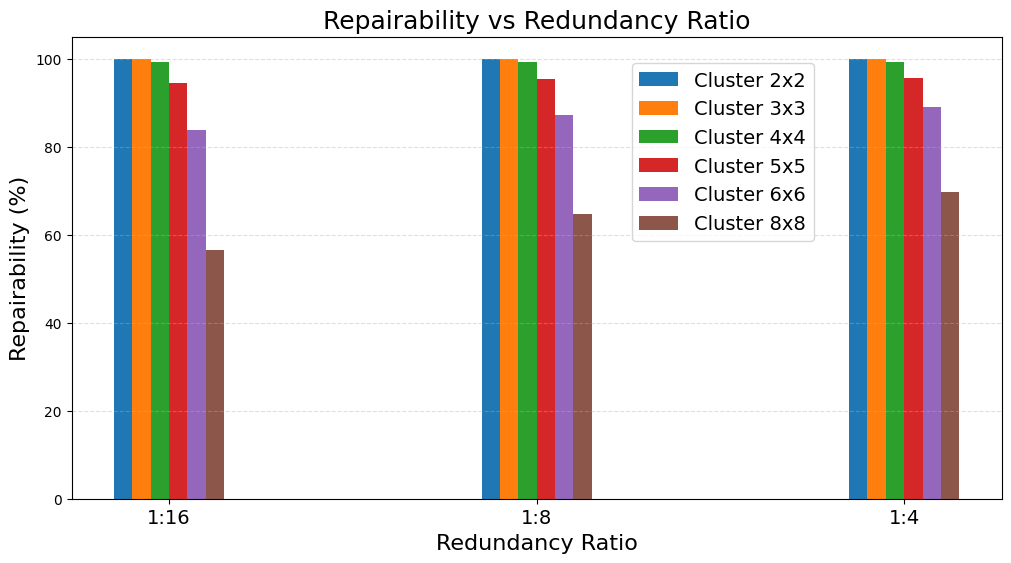

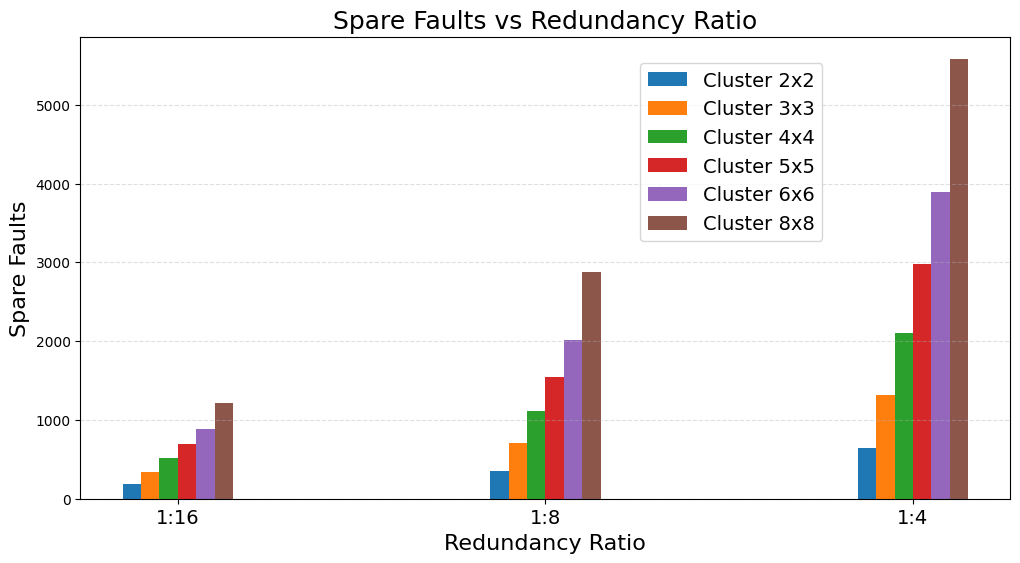

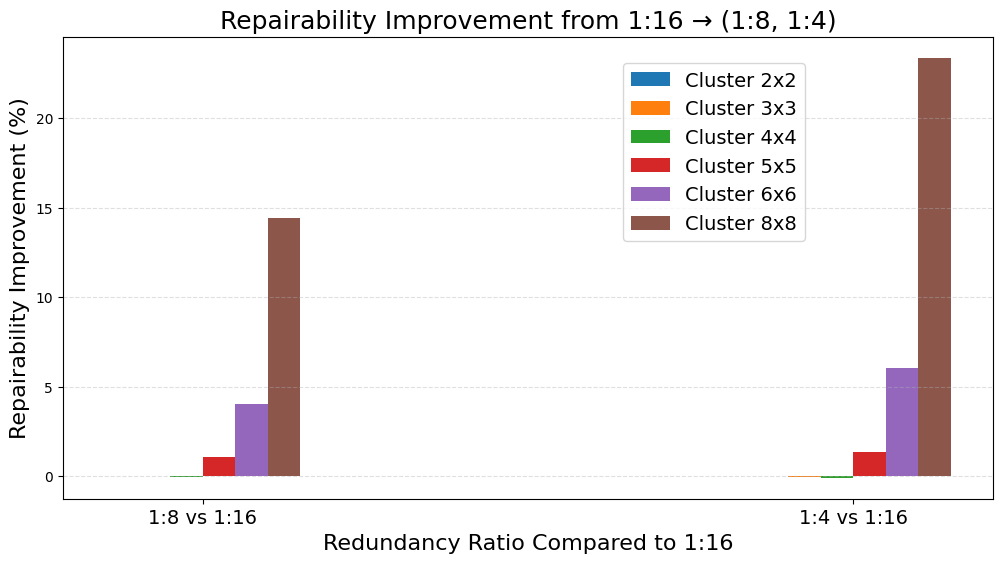

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# FONT / SIZE PARAMETERS (YOU CAN CHANGE LATER)
# ======================================================
fontsize_title = 18
fontsize_label = 16
fontsize_tick = 14
fontsize_legend = 14
bar_width = 0.05


# ======================================================
# REVERSE REDUNDANCY ORDER (16 → 8 → 4)
# ======================================================
redundancy_vals = sorted(
    list(set(row['redundancy_ratio'] for row in summary_table)),
    reverse=True
)

cluster_vals = sorted(list(set(row['cluster_size'] for row in summary_table)))

# ======================================================
# PREPARE MATRICES
# ======================================================
repair_rates = np.zeros((len(cluster_vals), len(redundancy_vals)))
unrepaired_vals = np.zeros_like(repair_rates)
ignored_vals = np.zeros_like(repair_rates)

for i, cs in enumerate(cluster_vals):
    for j, rr in enumerate(redundancy_vals):
        for row in summary_table:
            if row['cluster_size'] == cs and row['redundancy_ratio'] == rr:
                repair_rates[i, j] = row['repair_rate']
                unrepaired_vals[i, j] = row['unrepairable']
                ignored_vals[i, j] = row['ignored_spares']


# ======================================================
# GENERIC BAR PLOT FUNCTION
# ======================================================
def make_barplot(y_vals, ylabel, title):
    x = np.arange(len(redundancy_vals))
    plt.figure(figsize=(12, 6))

    for i, cs in enumerate(cluster_vals):
        plt.bar(
            x + i * bar_width,
            y_vals[i],
            width=bar_width,
            label=f"Cluster {cs}x{cs}"
        )

    xtick_positions = x + (len(cluster_vals) - 1) * bar_width / 2

    plt.xticks(
        xtick_positions,
        [f"1:{rr}" for rr in redundancy_vals],
        fontsize=fontsize_tick
    )

    plt.ylabel(ylabel, fontsize=fontsize_label)
    plt.xlabel("Redundancy Ratio", fontsize=fontsize_label)
    plt.title(title, fontsize=fontsize_title)

    plt.legend(
        fontsize=fontsize_legend,
        loc="center",
        bbox_to_anchor=(0.7, .75)
    )

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()



# ======================================================
# MAIN 3 PLOTS
# ======================================================

make_barplot(
    repair_rates,
    ylabel="Repairability (%)",
    title="Repairability vs Redundancy Ratio"
)

# make_barplot(
#     unrepaired_vals,
#     ylabel="Number of Unrepaired Faults",
#     title="Unrepaired Faults vs Redundancy Ratio"
# )

make_barplot(
    ignored_vals,
    ylabel="Spare Faults",
    title="Spare Faults vs Redundancy Ratio"
)



# ======================================================
# NEW PART: IMPROVEMENT PLOT (16 → 8, 16 → 4)
# ======================================================

def get_rr_value(cluster, rr):
    for row in summary_table:
        if row['cluster_size'] == cluster and row['redundancy_ratio'] == rr:
            return row['repair_rate']
    return None

improvement = np.zeros((len(cluster_vals), 2))  # for ratios (8, 4)

for i, cs in enumerate(cluster_vals):
    r16 = get_rr_value(cs, 16)
    r8  = get_rr_value(cs, 8)
    r4  = get_rr_value(cs, 4)

    improvement[i, 0] = ((r8 - r16) / r16) * 100
    improvement[i, 1] = ((r4 - r16) / r16) * 100


plt.figure(figsize=(12, 6))
x = np.arange(2)
labels = ["1:8 vs 1:16", "1:4 vs 1:16"]

for i, cs in enumerate(cluster_vals):
    plt.bar(
        x + i * bar_width,
        improvement[i],
        width=bar_width,
        label=f"Cluster {cs}x{cs}"
    )

xtick_positions = x + (len(cluster_vals)-1) * bar_width / 2
plt.xticks(xtick_positions, labels, fontsize=fontsize_tick)

plt.ylabel("Repairability Improvement (%)", fontsize=fontsize_label)
plt.xlabel("Redundancy Ratio Compared to 1:16", fontsize=fontsize_label)
plt.title("Repairability Improvement from 1:16 → (1:8, 1:4)", fontsize=fontsize_title)

plt.legend(
    fontsize=fontsize_legend,
    loc="center",
    bbox_to_anchor=(0.7, .75)
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


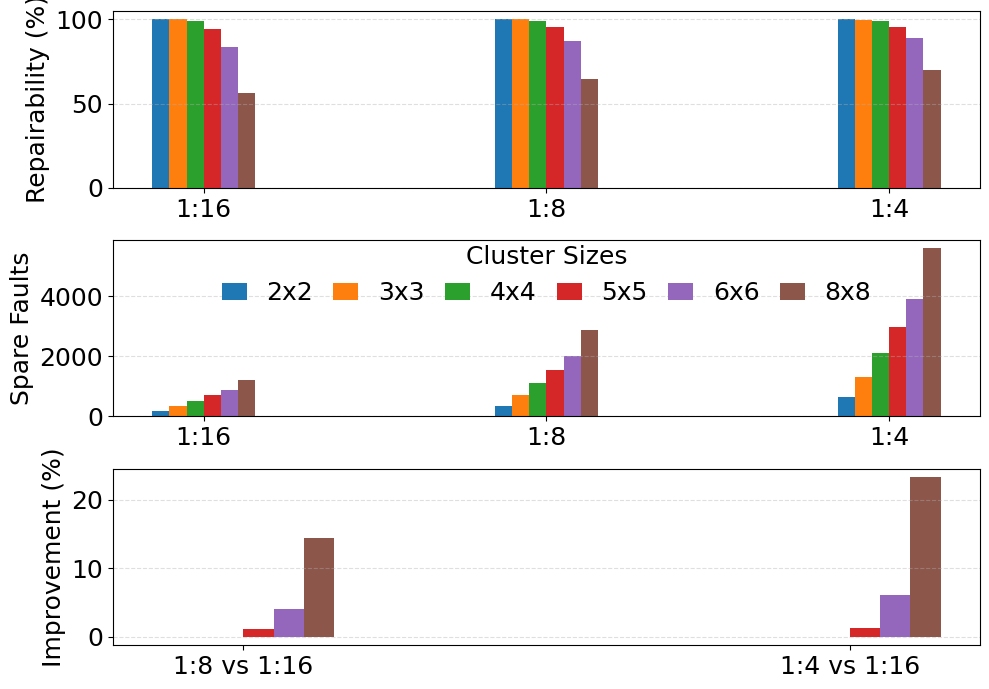

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# FONT / SIZE PARAMETERS (SAME AS BEFORE)
# ======================================================
fontsize_title = 18
fontsize_label = 18
fontsize_tick = 18
fontsize_legend = 18
bar_width = 0.05

# ======================================================
# REVERSE REDUNDANCY ORDER (16 → 8 → 4)
# ======================================================
redundancy_vals = sorted(
    list(set(row['redundancy_ratio'] for row in summary_table)),
    reverse=True
)

cluster_vals = sorted(list(set(row['cluster_size'] for row in summary_table)))

# ======================================================
# PREPARE MATRICES
# ======================================================
repair_rates = np.zeros((len(cluster_vals), len(redundancy_vals)))
ignored_vals = np.zeros_like(repair_rates)

for i, cs in enumerate(cluster_vals):
    for j, rr in enumerate(redundancy_vals):
        for row in summary_table:
            if row['cluster_size'] == cs and row['redundancy_ratio'] == rr:
                repair_rates[i, j] = row['repair_rate']
                ignored_vals[i, j] = row['ignored_spares']


# ======================================================
# IMPROVEMENT MATRIX (8→16, 4→16)
# ======================================================
def get_rr_value(cluster, rr):
    for row in summary_table:
        if row['cluster_size'] == cluster and row['redundancy_ratio'] == rr:
            return row['repair_rate']
    return None

improvement = np.zeros((len(cluster_vals), 2))

for i, cs in enumerate(cluster_vals):
    r16 = get_rr_value(cs, 16)
    r8  = get_rr_value(cs, 8)
    r4  = get_rr_value(cs, 4)

    improvement[i, 0] = ((r8 - r16) / r16) * 100
    improvement[i, 1] = ((r4 - r16) / r16) * 100


# ======================================================
# =======  SINGLE FIGURE WITH 3 SUBPLOTS  ===============
# ======================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 7))
titles = [
    "Repairability vs Redundancy Ratio",
    "Spare Faults vs Redundancy Ratio",
    "Repairability Improvement (vs 1:16)"
]
ylabels = [
    "Repairability (%)",
    "Spare Faults",
    "Improvement (%)"
]

# ---------- SUBPLOT 1: Repairability ----------
ax = axes[0]
x = np.arange(len(redundancy_vals))

for i, cs in enumerate(cluster_vals):
    ax.bar(
        x + i * bar_width,
        repair_rates[i],
        width=bar_width,
        label=f"{cs}x{cs}"
    )

ax.set_xticks(x + (len(cluster_vals) - 1) * bar_width / 2)
ax.set_xticklabels([f"1:{rr}" for rr in redundancy_vals], fontsize=fontsize_tick)
#ax.set_title(titles[0], fontsize=fontsize_title)
ax.set_ylabel(ylabels[0], fontsize=fontsize_label)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='y', labelsize=fontsize_tick)
# ---------- SUBPLOT 2: Spare Faults ----------
ax = axes[1]

bars = []
for i, cs in enumerate(cluster_vals):
    bars.append(
        ax.bar(
            x + i * bar_width,
            ignored_vals[i],
            width=bar_width,
            label=f"{cs}x{cs}"
        )
    )

ax.set_xticks(x + (len(cluster_vals) - 1) * bar_width / 2)
ax.set_xticklabels([f"1:{rr}" for rr in redundancy_vals], fontsize=fontsize_tick)
#ax.set_title(titles[1], fontsize=fontsize_title)
ax.set_ylabel(ylabels[1], fontsize=fontsize_label)
ax.tick_params(axis='y', labelsize=fontsize_tick)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ⭐⭐ Move the legend HERE ⭐⭐
handles, labels = axes[0].get_legend_handles_labels()
leg = ax.legend(
    handles,
    labels,
    title="Cluster Sizes",
    fontsize=fontsize_legend,
    title_fontsize=fontsize_legend,
    ncol=len(cluster_vals),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    handlelength=1.0,
    columnspacing=0.8
)
leg.get_frame().set_alpha(0.0)   # <-- TRANSPARENT LEGEND BOX


# ---------- SUBPLOT 3: Improvement ----------
ax = axes[2]
x_impr = np.arange(2)
labels_impr = ["1:8 vs 1:16", "1:4 vs 1:16"]

for i, cs in enumerate(cluster_vals):
    ax.bar(
        x_impr + i * bar_width,
        improvement[i],
        width=bar_width
    )

ax.set_xticks(x_impr + (len(cluster_vals) - 1) * bar_width / 2)
ax.set_xticklabels(labels_impr, fontsize=fontsize_tick)
ax.tick_params(axis='y', labelsize=fontsize_tick)
#ax.set_title(titles[2], fontsize=fontsize_title)
ax.set_ylabel(ylabels[2], fontsize=fontsize_label)
ax.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()
